In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'Online-Retail-France.xlsx'
random_state = 42

np.random.seed(random_state)

### Upload the file Online-Retail-France.xlsx. It is a MS Excel file, you can read it with the Pandas function read_excel, show the size and a small portion of its content

In [2]:
df = pd.read_excel(file_name)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0


In [3]:
print(f"rows: {df.shape[0]} cols:{df.shape[1]}")

rows: 8557 cols:7


###  Print the number of unique Description values

In [4]:
n=df['Description'].nunique()
print(n)

1565


### uniform with the Pandas function str.strip() Print the number of unique Description values after this cleaning 

In [5]:
dfclean=df
dfclean['Description']=[str.strip(d) for d in df['Description'] ]
dfclean=pd.DataFrame(dfclean)
dfclean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0


In [6]:
print(dfclean['Description'].nunique())

1564


### Some rows may not have an InvoiceNo and must be removed, because they cannot be used. Check if there are such that rows and in case remove them. Inspect the effect of this cleaning

In [7]:
dfclean=dfclean.dropna(subset=['InvoiceNo'])
dfclean.shape

(8557, 7)

In [8]:
dfclean[dfclean['InvoiceNo'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID


###  Some InvoiceNo start with a C. They are "credit transactions" and must be removed. Inspect the effect of this cleaning

In [9]:
print("There are {} rows containing 'C' in 'InvoiceNo'"\
      .format(sum(dfclean['InvoiceNo'].str.contains('C'))))
      # .format(sum(df2['InvoiceNo'].astype('str').str.contains('C'))))

There are 149 rows containing 'C' in 'InvoiceNo'


In [10]:
dffinal=dfclean[~dfclean['InvoiceNo'].str.startswith("C")]
dffinal.shape

(8408, 7)

In [11]:
print("There are {} rows containing 'C' in 'InvoiceNo'"\
      .format(sum(dffinal['InvoiceNo'].str.contains('C'))))
      # .format(sum(df2['InvoiceNo'].astype('str').str.contains('C'))))

There are 0 rows containing 'C' in 'InvoiceNo'


### In this analysis we are not interested in it, therefore the rows with item POSTAGE will be removed.

In [12]:
container = 'Description'
target = 'POSTAGE'
print("There are {} rows containing {} in {}"\
      .format(sum(dffinal[container].str.contains(target)), target, container))

There are 300 rows containing POSTAGE in Description


In [13]:
dffinal= dffinal[~dffinal['Description'].str.contains("POSTAGE")]
dffinal.shape

(8108, 7)

In [14]:
container = 'Description'
target = 'POSTAGE'
print("There are {} rows containing {} in {}"\
      .format(sum(dffinal[container].str.contains(target)), target, container))

There are 0 rows containing POSTAGE in Description


### consolidate the items into one transaction per row with products one–hot–encoded. To do so, group by InvoiceNo and Description computing a sum on Quantity, use the Pandas unstack function to move the items from rows to columns, reset the index, fill the missing with zero, store the result in a new dataframe basket and inspect it.

In [23]:
basket=dffinal.groupby(['InvoiceNo','Description'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('InvoiceNo')
basket.head()

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536974,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
537065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
537463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### convert to True the positive values and to False the non–positive values. Inspect the result of this transformation and verify the correctness

In [26]:
def tobool(x):
    if x < 1:
        return False
    else:
        return True

basket_enc=basket.map(tobool)
basket_enc.head()

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536370,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536852,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536974,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
537065,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
537463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


###  find the maximum value of min_support such that the number of rules generated from the frequent itemsets with lift not less than 1 is at least 20. Show the value obtained for min_support and show the rules.
Hint: use a loop with an initial value min_support=1 and decrease it in
steps -0.01
Hint: In apriori set the parameter use_colnames=True

In [37]:
min_itemsets = 20
min_item_in_itemset = 1
# "Reasonable" range
support_range = np.arange(0.1, 0.01, -0.01)
current_metric = "lift"
metric_value=1
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
min_support = 0
for s_value in support_range:
    print(f"Trying support value {s_value:.2f}")
    frequent_itemsets = apriori(basket_enc, min_support = s_value, use_colnames = True)
    rules = association_rules(frequent_itemsets, metric=current_metric, min_threshold=metric_value)
    if rules.shape[0] >= min_itemsets:
        min_support = s_value
        break
if min_support == 0:
    print("No itemset found! Try again with a bigger range!")
else:
    print(f"I've selected min_support = {min_support:.2f}, which produced , {len(frequent_itemsets)} itemsets, {itemsets_above_threshold} of which had more than {min_item_in_itemset} items n of rules:{rules.shape[0]}")

Trying support value 0.10
Trying support value 0.09
Trying support value 0.08
I've selected min_support = 0.08, which produced , 41 itemsets, 29 of which had more than 1 items n of rules:20


In [39]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.095607,0.098191,0.080103,0.837838,8.532717,1.0,0.070716,5.561154,0.976129,0.704545,0.820181,0.826814
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.098191,0.095607,0.080103,0.815789,8.532717,1.0,0.070716,4.909561,0.978926,0.704545,0.796316,0.826814
2,(PLASTERS IN TIN CIRCUS PARADE),(PLASTERS IN TIN SPACEBOY),0.170543,0.139535,0.090439,0.530303,3.800505,1.0,0.066643,1.831958,0.888385,0.411765,0.454136,0.589226
3,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN CIRCUS PARADE),0.139535,0.170543,0.090439,0.648148,3.800505,1.0,0.066643,2.357405,0.856371,0.411765,0.575805,0.589226
4,(PLASTERS IN TIN CIRCUS PARADE),(PLASTERS IN TIN WOODLAND ANIMALS),0.170543,0.173127,0.103359,0.606061,3.500678,1.0,0.073834,2.098986,0.861215,0.430108,0.523580,0.601538
5,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN CIRCUS PARADE),0.173127,0.170543,0.103359,0.597015,3.500678,1.0,0.073834,2.058283,0.863906,0.430108,0.514158,0.601538
6,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN SPACEBOY),0.173127,0.139535,0.105943,0.611940,4.385572,1.0,0.081786,2.217352,0.933613,0.512500,0.549012,0.685600
7,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.139535,0.173127,0.105943,0.759259,4.385572,1.0,0.081786,3.434705,0.897165,0.512500,0.708854,0.685600
8,(SET/20 RED RETROSPOT PAPER NAPKINS),(SET/6 RED SPOTTY PAPER CUPS),0.134367,0.139535,0.103359,0.769231,5.512821,1.0,0.084610,3.728682,0.945672,0.606061,0.731809,0.754986
9,(SET/6 RED SPOTTY PAPER CUPS),(SET/20 RED RETROSPOT PAPER NAPKINS),0.139535,0.134367,0.103359,0.740741,5.512821,1.0,0.084610,3.338870,0.951351,0.606061,0.700498,0.754986


### In order to scatter–plot some information about the rules, it is better to sort them according to some metrics. We will sort on descending lift and confidence, then do a scatter plot of them.

<Axes: title={'center': 'zebbi'}, xlabel='lift', ylabel='confidence'>

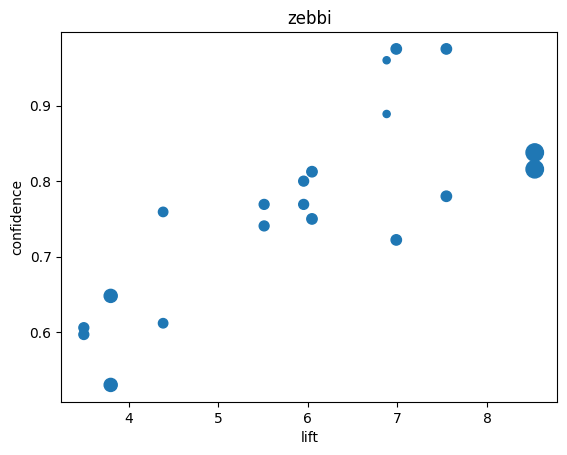

In [49]:
sorted_rules=rules.sort_values(by=['lift','confidence'],ascending=False).reset_index(drop=True)
s=[1.5**(n**-1) for n in rules.support]
rules.plot.scatter(x='lift',y='confidence',title='zebbi', s=s)